# Coffee Chain Sales Analysis
### Introduction
This dataset provides comprehensive sales and financial performance data for a coffee chain across various regions in the United States, spanning from October 2012 to March 2015. It contains **2,764 records** with **21 key attributes**, including regional identifiers, product categories, sales figures, costs, profit margins, and performance against targets.  


This analysis will explore regional performance variations, product profitability, seasonal trends, and areas where the business exceeds or falls short of expectations. By identifying patterns in sales, costs, and profit margins, we can derive actionable insights to optimize pricing, inventory management, and marketing strategies for improved financial performance.

### Key Attributes:

1.Area Code: A unique identifier for different geographical areas or regions where the coffee chain operates.

2.COGS (Cost of Goods Sold): The total cost incurred by the coffee chain in producing or purchasing the products it sells.

3.Difference between Actual and Target Profit: This attribute indicates how well the company performed in terms of profit compared to its target. It reflects the financial performance against predefined goals.

4.Date: The date of sales transactions, which allows for time-based analysis of sales trends and patterns.

5.Inventory Margin: The difference between the cost of maintaining inventory and the revenue generated from selling those inventory items.

6.Margin: The profit margin, which is the percentage of profit earned from sales. It's a critical financial metric.

7.Market Size: Information about the size of the market in each area, helping to understand the potential customer base and market dynamics.

8.Profit: financial gain achieved by the company after deducting the cost of goods sold (COGS) and other expenses from the revenue generated through sales.

9.Sales: represent the revenue generated from the coffee chain's products, reflecting its financial performance and customer demand.

### Required Libraries

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer
from pylab import rcParams
from pathlib import Path

import seaborn as sns

### Load Dataset

In [6]:
# Create directory for images 
Path("img").mkdir(parents=True, exist_ok=True)

# Set default figure size
rcParams['figure.figsize'] = (4, 4)

# Tell pandas how to display floats
pd.options.display.float_format = "{:,.2f}".format

In [7]:
path = 'Downloads/Coffee_Chain_Sales .csv'

In [8]:
df = pd.read_csv(path)

### Initial Exploration

In [10]:
df.head()

,Area Code,Cogs,DifferenceBetweenActualandTargetProfit,Date,Inventory Margin,Margin,Market_size,Market,Marketing,Product_line,...,Product,Profit,Sales,State,Target_cogs,Target_margin,Target_profit,Target_sales,Total_expenses,Type
0,303,51,-35,10/1/2012,503,71,Major Market,Central,46,Leaves,...,Lemon,-5,122,Colorado,30,60,30,90,76,Decaf
1,970,52,-24,10/1/2012,405,71,Major Market,Central,17,Leaves,...,Mint,26,123,Colorado,30,60,50,90,45,Decaf
2,409,43,-22,10/2/2012,419,64,Major Market,South,13,Leaves,...,Lemon,28,107,Texas,30,60,50,90,36,Decaf
3,850,38,-15,10/3/2012,871,56,Major Market,East,10,Leaves,...,Darjeeling,35,94,Florida,40,60,50,100,21,Regular
4,562,72,6,10/4/2012,650,110,Major Market,West,23,Leaves,...,Green Tea,56,182,California,20,60,50,80,54,Regular


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Area Code                               1062 non-null   int64 
 1   Cogs                                    1062 non-null   int64 
 2   DifferenceBetweenActualandTargetProfit  1062 non-null   int64 
 3   Date                                    1062 non-null   object
 4   Inventory Margin                        1062 non-null   int64 
 5   Margin                                  1062 non-null   int64 
 6   Market_size                             1062 non-null   object
 7   Market                                  1062 non-null   object
 8   Marketing                               1062 non-null   int64 
 9   Product_line                            1062 non-null   object
 10  Product_type                            1062 non-null   object
 11  Prod

In [12]:
df.isnull().sum()

Area Code                                 0
Cogs                                      0
DifferenceBetweenActualandTargetProfit    0
Date                                      0
Inventory Margin                          0
Margin                                    0
Market_size                               0
Market                                    0
Marketing                                 0
Product_line                              0
Product_type                              0
Product                                   0
Profit                                    0
Sales                                     0
State                                     0
Target_cogs                               0
Target_margin                             0
Target_profit                             0
Target_sales                              0
Total_expenses                            0
Type                                      0
dtype: int64

In [13]:
df.nunique()

Area Code                                  149
Cogs                                       100
DifferenceBetweenActualandTargetProfit     200
Date                                      1061
Inventory Margin                           205
Margin                                     140
Market_size                                  2
Market                                       4
Marketing                                   67
Product_line                                 2
Product_type                                 4
Product                                     13
Profit                                     238
Sales                                      243
State                                       20
Target_cogs                                 37
Target_margin                               56
Target_profit                               50
Target_sales                                68
Total_expenses                              95
Type                                         2
dtype: int64

In [14]:
df.shape

(1062, 21)

In [15]:
df.describe()

,Area Code,Cogs,DifferenceBetweenActualandTargetProfit,Inventory Margin,Margin,Marketing,Profit,Sales,Target_cogs,Target_margin,Target_profit,Target_sales,Total_expenses
count,"1,062.00","1,062.00","1,062.00","1,062.00","1,062.00","1,062.00","1,062.00","1,062.00","1,062.00","1,062.00","1,062.00","1,062.00","1,062.00"
mean,587.03,82.40,0.39,815.18,102.42,30.43,60.56,191.05,71.68,96.82,60.17,168.49,53.84
std,225.30,64.82,44.33,916.16,91.29,25.96,100.52,148.27,65.70,89.47,77.82,145.96,31.70
min,203.00,0.00,-369.00,"-3,534.00",-294.00,0.00,-605.00,21.00,0.00,-210.00,-320.00,0.00,11.00
25%,425.00,41.00,-15.00,447.00,51.00,13.00,16.25,98.00,30.00,50.00,20.00,80.00,33.00
50%,573.00,57.00,-3.00,659.00,73.00,22.00,39.50,133.00,50.00,70.00,40.00,120.00,46.00
75%,774.00,101.00,13.00,968.00,130.00,40.75,87.00,227.00,90.00,120.00,80.00,210.00,66.00
max,985.00,294.00,249.00,"8,252.00",526.00,122.00,646.00,815.00,380.00,580.00,470.00,960.00,156.00


### Visualizations

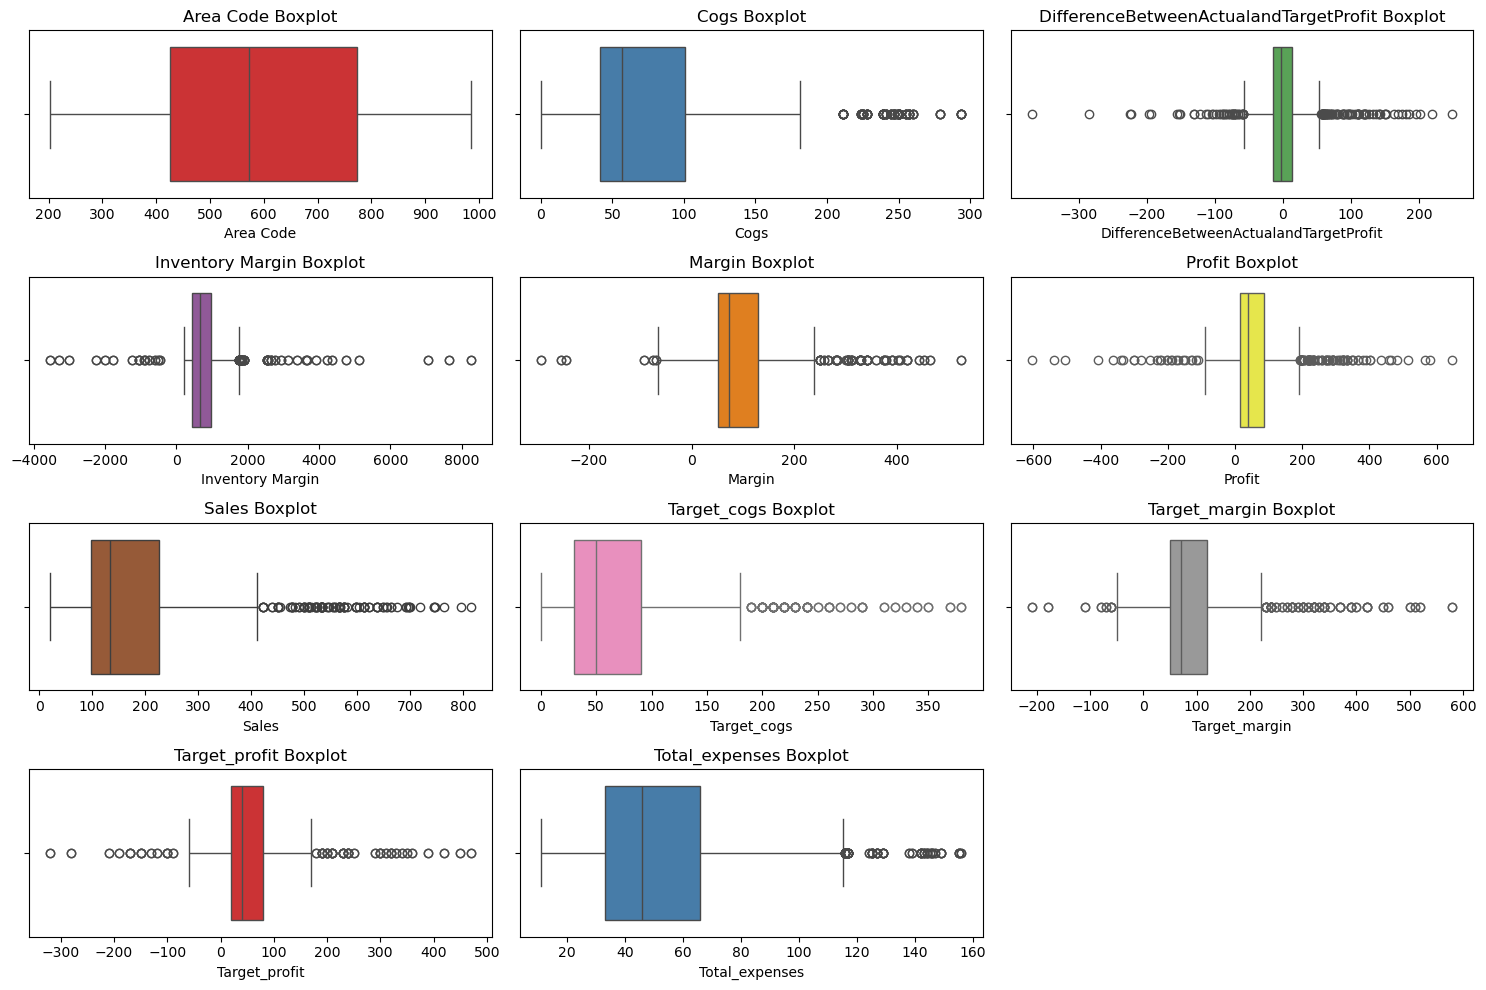

In [17]:
col_box = ['Area Code', 'Cogs', 'DifferenceBetweenActualandTargetProfit',
          'Inventory Margin', 'Margin', 'Profit', 'Sales', 'Target_cogs',
          'Target_margin', 'Target_profit', 'Total_expenses']
color_palette = sns.color_palette("Set1", len(col_box))
plt.figure(figsize = (15, 10))

for i, column in enumerate(col_box, 1):
    plt.subplot((len(col_box)//3)+1, 3, i)
    sns.boxplot(data=df, x=column, color=color_palette[i - 1])    
    plt.xlabel(column)
    plt.title(f'{column} Boxplot')

plt.tight_layout()
plt.show()

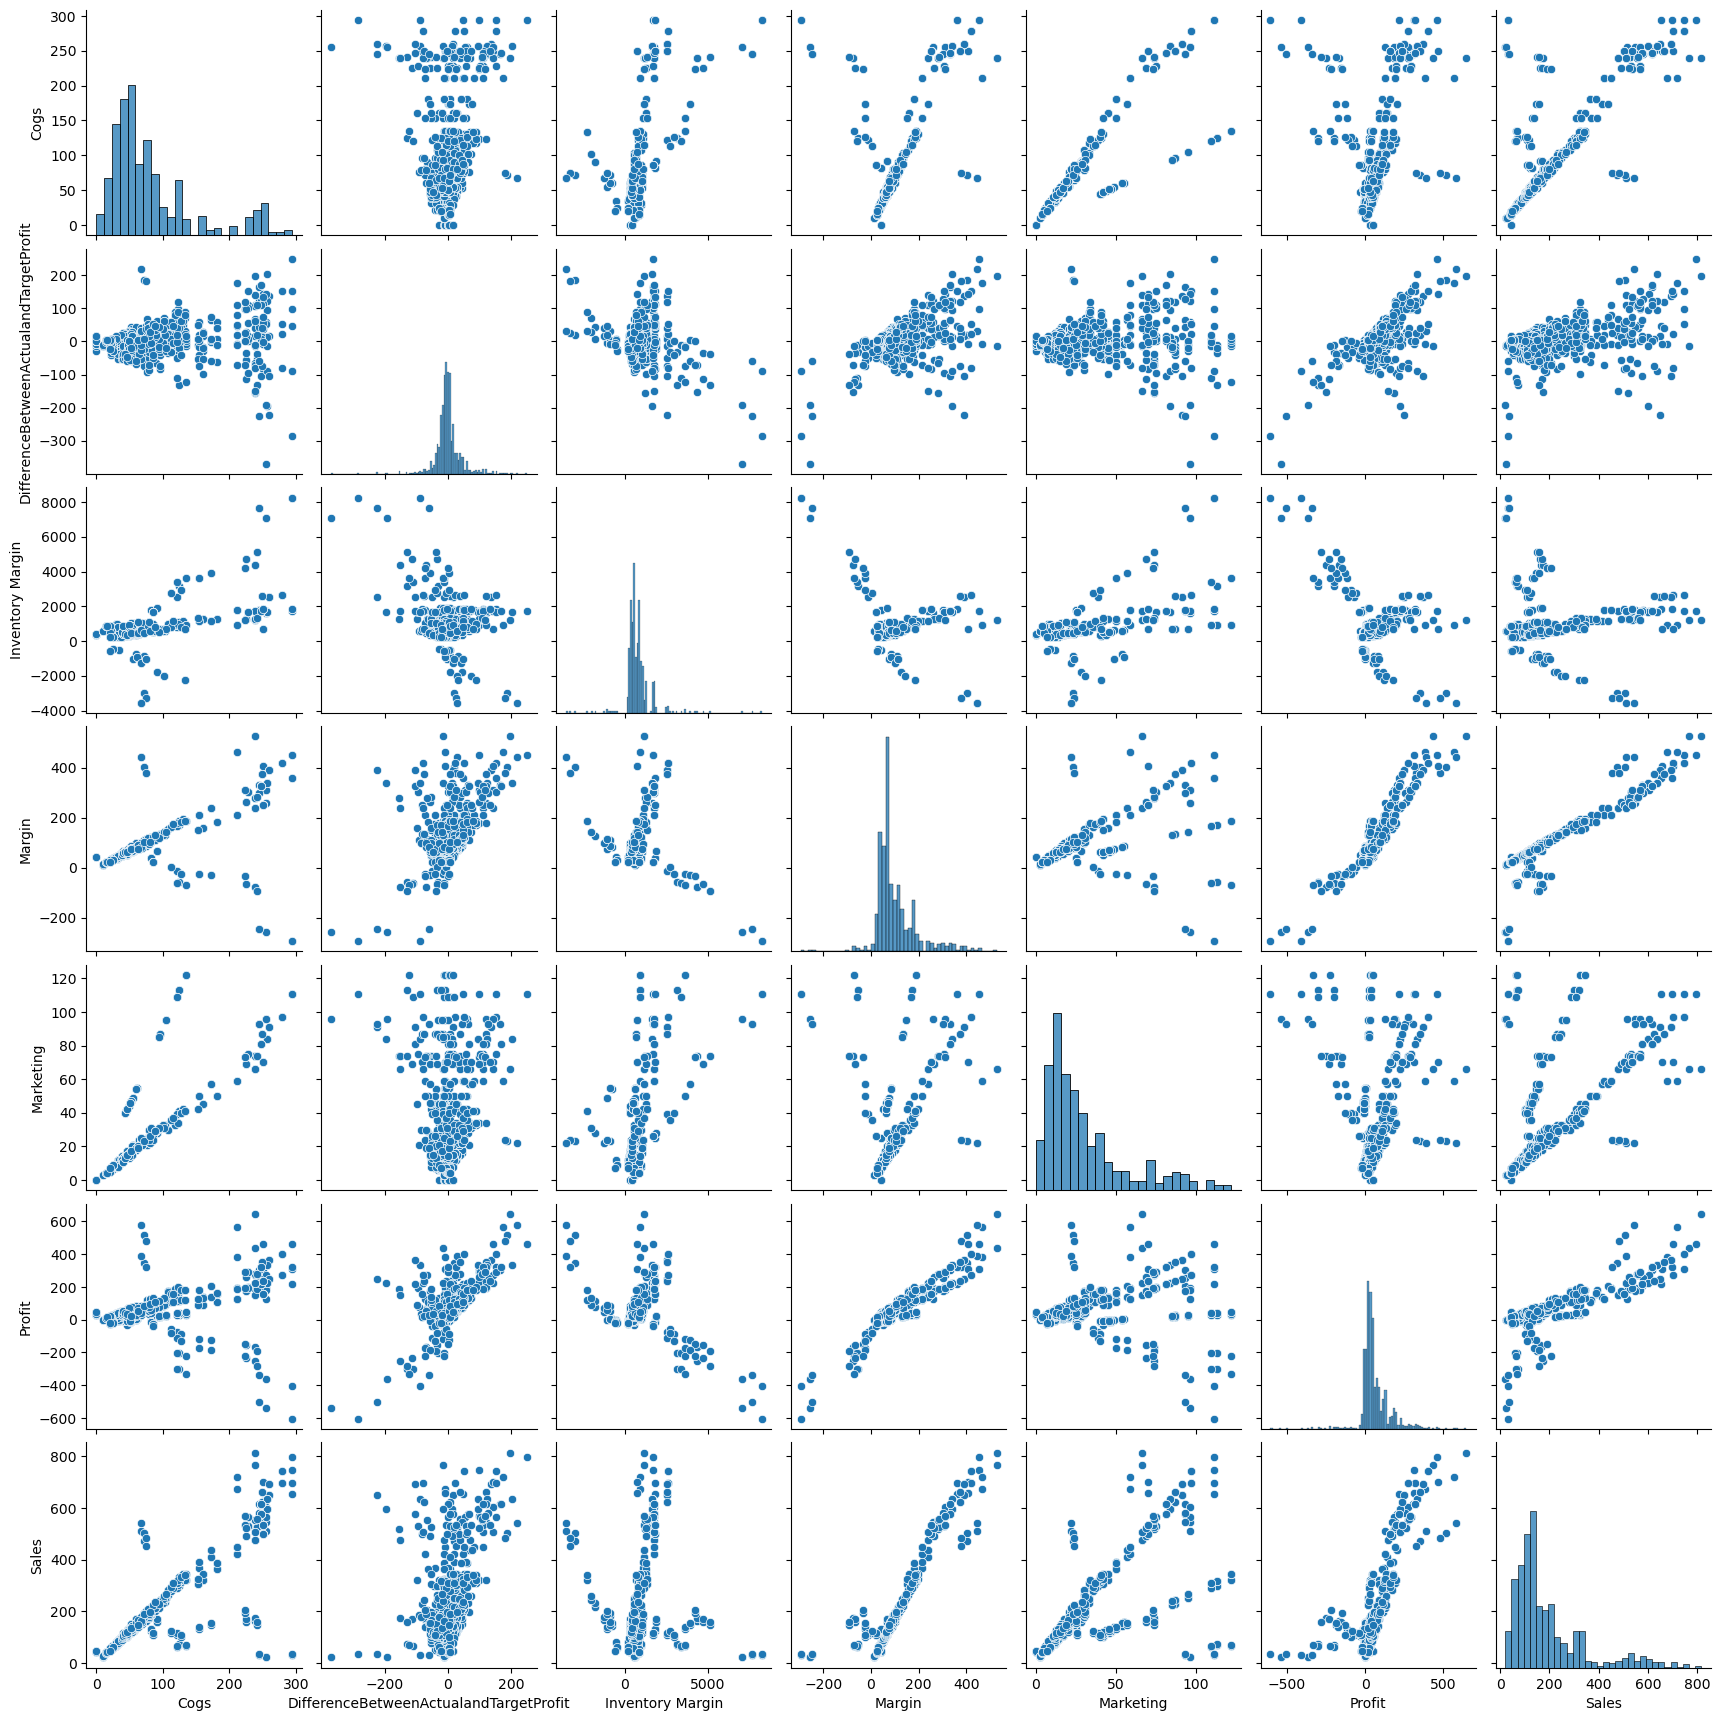

In [18]:
sns.pairplot(df.loc[:,'Cogs':'Sales'])

In [19]:
df['Month'] = pd.to_datetime(df['Date']).dt.month
df['Year'] = pd.to_datetime(df['Date']).dt.year

<Axes: title={'center': 'Total Profit by Year'}, xlabel='Year'>

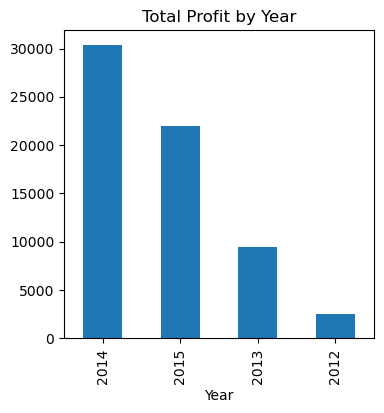

In [20]:
# Total Profit by Year
total_profit_by_year = df.groupby('Year')['Profit'].sum().sort_values(ascending=False)
total_profit_by_year.plot(kind='bar', title="Total Profit by Year")

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, 'Colombian'),
  Text(1, 0, 'Lemon'),
  Text(2, 0, 'Caffe Mocha'),
  Text(3, 0, 'Chamomile'),
  Text(4, 0, 'Decaf Espresso'),
  Text(5, 0, 'Darjeeling'),
  Text(6, 0, 'Earl Grey'),
  Text(7, 0, 'Decaf Irish Cream'),
  Text(8, 0, 'Caffe Latte'),
  Text(9, 0, 'Green Tea'),
  Text(10, 0, 'Mint'),
  Text(11, 0, 'Amaretto'),
  Text(12, 0, 'Regular Espresso')])

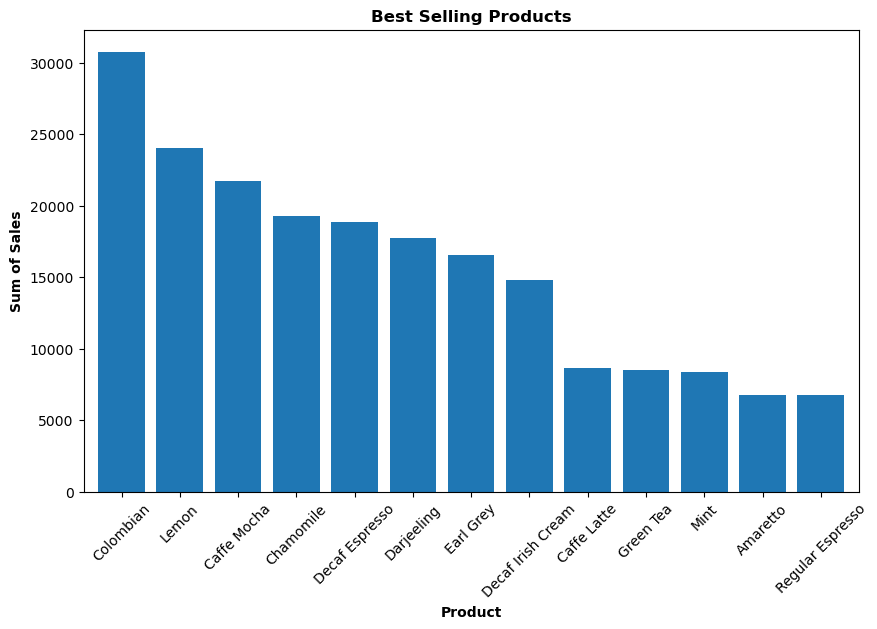

In [21]:
# Best selling products by units sold
grouped = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)
grouped.plot(kind='bar', figsize=(10, 6), width=0.8)
plt.xlabel('Product', fontweight='bold')
plt.ylabel('Sum of Sales', fontweight='bold')
plt.title('Best Selling Products', fontweight='bold')
plt.xticks(rotation=45)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, 'Colombian'),
  Text(1, 0, 'Lemon'),
  Text(2, 0, 'Caffe Mocha'),
  Text(3, 0, 'Chamomile'),
  Text(4, 0, 'Decaf Espresso'),
  Text(5, 0, 'Darjeeling'),
  Text(6, 0, 'Earl Grey'),
  Text(7, 0, 'Decaf Irish Cream'),
  Text(8, 0, 'Caffe Latte'),
  Text(9, 0, 'Green Tea'),
  Text(10, 0, 'Mint'),
  Text(11, 0, 'Amaretto'),
  Text(12, 0, 'Regular Espresso')])

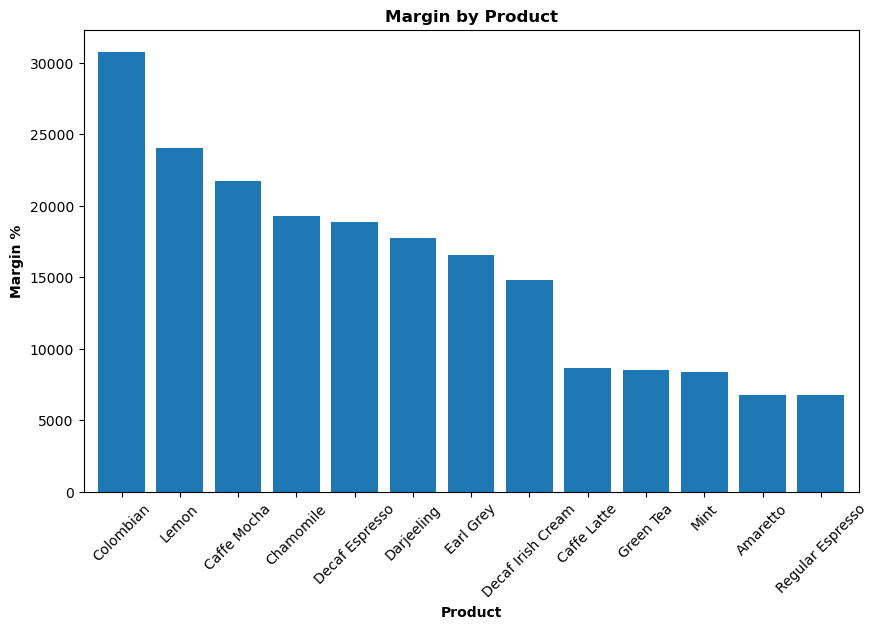

In [22]:
# Group by Product and calculate average Inventory Margin for each product
df.groupby('Product')['Margin'].mean().sort_values(ascending=True)
grouped.plot(kind='bar', figsize=(10, 6), width=0.8)
plt.xlabel('Product', fontweight='bold')
plt.ylabel('Margin %', fontweight='bold')
plt.title('Margin by Product', fontweight='bold')
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Profit vs Target DIfference by State')

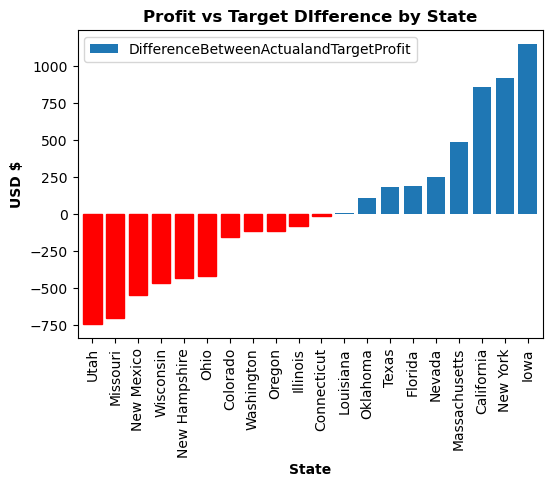

In [23]:
# Plotting bar chart for Marketing vs Profit by State

grouped = df.groupby('State')[['DifferenceBetweenActualandTargetProfit']].sum().sort_values(by='DifferenceBetweenActualandTargetProfit', ascending=True)
ax = grouped.plot(kind='bar', figsize=(6, 4), width=0.8,)

for bar in ax.patches:
    if bar.get_height() < 0:
        bar.set_color('red')

plt.xlabel('State', fontweight='bold')
plt.ylabel('USD $', fontweight='bold')
plt.title('Profit vs Target DIfference by State', fontweight='bold')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, 'California'),
  Text(1, 0, 'Colorado'),
  Text(2, 0, 'Connecticut'),
  Text(3, 0, 'Florida'),
  Text(4, 0, 'Illinois'),
  Text(5, 0, 'Iowa'),
  Text(6, 0, 'Louisiana'),
  Text(7, 0, 'Massachusetts'),
  Text(8, 0, 'Missouri'),
  Text(9, 0, 'Nevada'),
  Text(10, 0, 'New Hampshire'),
  Text(11, 0, 'New Mexico'),
  Text(12, 0, 'New York'),
  Text(13, 0, 'Ohio'),
  Text(14, 0, 'Oklahoma'),
  Text(15, 0, 'Oregon'),
  Text(16, 0, 'Texas'),
  Text(17, 0, 'Utah'),
  Text(18, 0, 'Washington'),
  Text(19, 0, 'Wisconsin')])

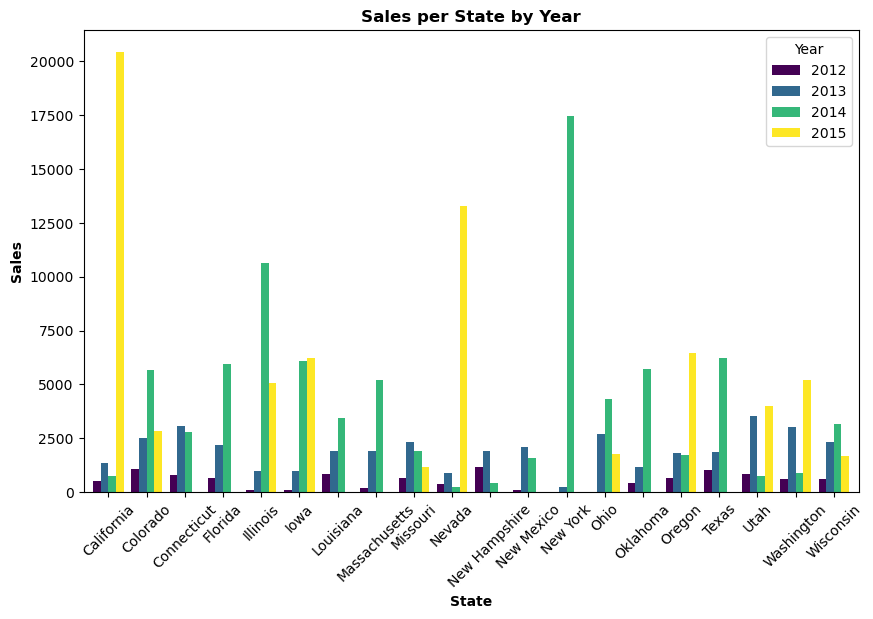

In [24]:
# Plotting bar chart for total sales in individual states for every year

grouped = df.groupby(['State', 'Year'])['Sales'].sum().unstack()

# Create a bar plot
ax = grouped.plot(kind='bar', figsize=(10, 6), width=0.8, colormap='viridis')
plt.xlabel('State', fontweight='bold')
plt.ylabel('Sales', fontweight='bold')
plt.title('Sales per State by Year', fontweight='bold')
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Marketing and Sales for the State of Utah per Year')

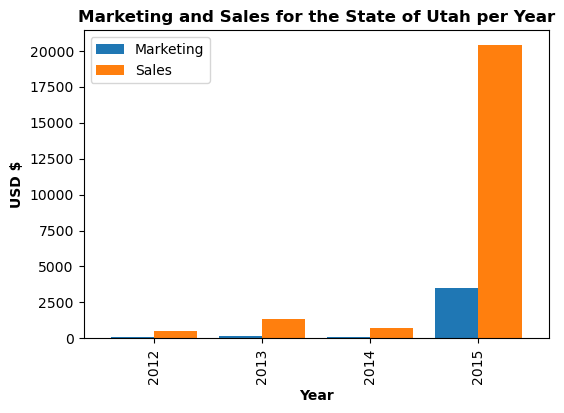

In [25]:
# Lets look into the worse & best performing states
# Filter data for the state of California
california_data = df[df['State'] == 'California']

grouped = california_data.groupby('Year')[['Marketing', 'Sales']].sum()
grouped.plot(kind='bar', figsize=(6, 4), width=0.8)

plt.xlabel('Year', fontweight='bold')
plt.ylabel('USD $', fontweight='bold')
plt.title('Marketing and Sales for the State of Utah per Year', fontweight='bold')

(array([0, 1, 2, 3]),
 [Text(0, 0, '2012'),
  Text(1, 0, '2013'),
  Text(2, 0, '2014'),
  Text(3, 0, '2015')])

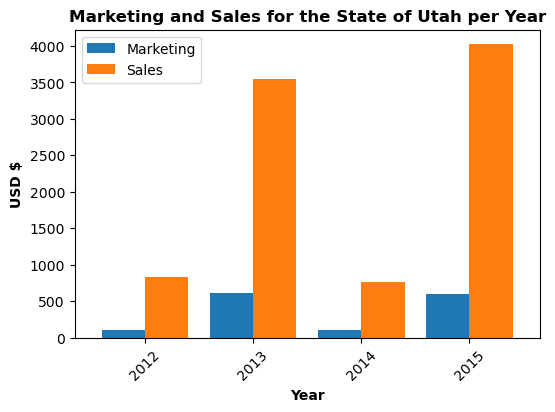

In [26]:
# Filter data for the state of Utah
utah_data = df[df['State'] == 'Utah']

grouped = utah_data.groupby('Year')[['Marketing', 'Sales']].sum()
grouped.plot(kind='bar', figsize=(6, 4), width=0.8)

plt.xlabel('Year', fontweight='bold')
plt.ylabel('USD $', fontweight='bold')
plt.title('Marketing and Sales for the State of Utah per Year', fontweight='bold')
plt.xticks(rotation=45)

In [27]:
# Calculating the Avergae Inventory Margin 

avg_inv_margin = df['Margin'].mean()
formatted_avg_inventory_margin = '{:.2f}'.format(avg_inv_margin)

print("Average Inventory Margin:\n", formatted_avg_inventory_margin, "%")

Average Inventory Margin:
 102.42 %


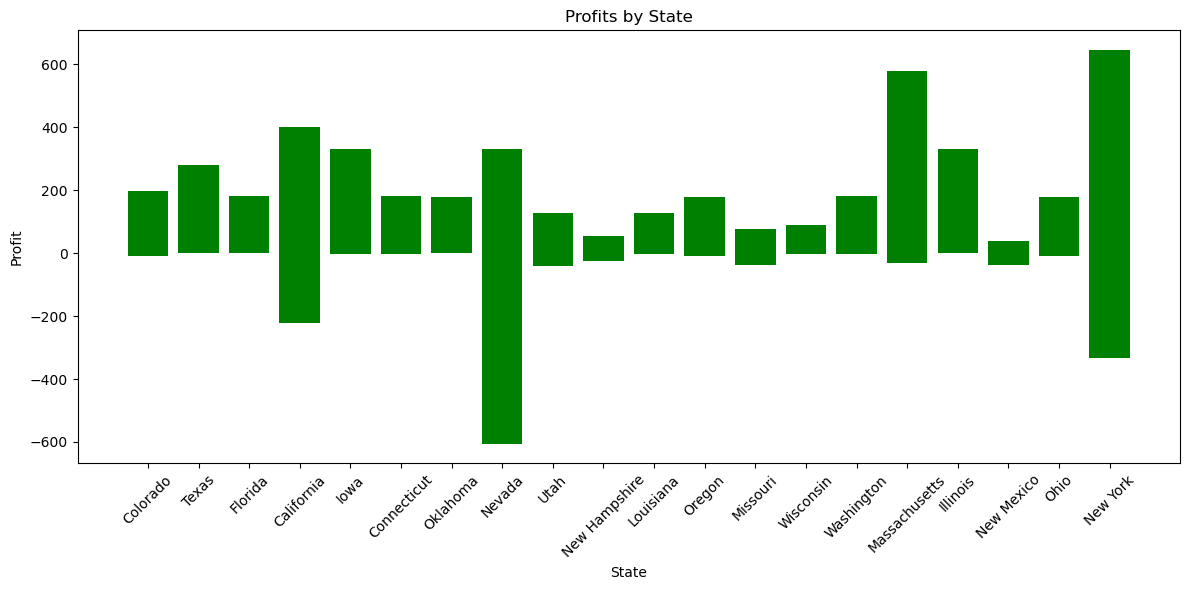

In [58]:
#bar plot to show profits by state 
plt.figure(figsize=(12, 6))
plt.bar(df['State'], df['Profit'], color='g')
plt.xlabel('State')
plt.ylabel('Profit')
plt.title('Profits by State')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()